In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

In [3]:
df=pd.read_csv('Zom.csv')

In [4]:
df.head(10)

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1/5,775,800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,300,Buffet
4,Grand Village,No,No,3.8/5,166,600,Buffet
5,Timepass Dinner,Yes,No,3.8/5,286,600,Buffet
6,Rosewood International Hotel - Bar & Restaurant,No,No,3.6/5,8,800,Buffet
7,Onesta,Yes,Yes,4.6/5,2556,600,Cafes
8,Penthouse Cafe,Yes,No,4.0/5,324,700,other
9,Smacznego,Yes,No,4.2/5,504,550,Cafes


In [5]:
df.isnull().any()

,0
name,False
online_order,False
book_table,False
rate,False
votes,False
approx_cost(for two people),False
listed_in(type),False


In [6]:
df.isnull().sum()

,0
name,0
online_order,0
book_table,0
rate,0
votes,0
approx_cost(for two people),0
listed_in(type),0


In [7]:
df['rate'].dtype

dtype('O')

In [8]:
df.dtypes

,0
name,object
online_order,object
book_table,object
rate,object
votes,int64
approx_cost(for two people),int64
listed_in(type),object


In [9]:
print(df.shape)
df.info()
df.nunique()
df.dropna(subset=['rate', 'votes', 'approx_cost(for two people)'], inplace=True)

(148, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   name                         148 non-null    object
 1   online_order                 148 non-null    object
 2   book_table                   148 non-null    object
 3   rate                         148 non-null    object
 4   votes                        148 non-null    int64 
 5   approx_cost(for two people)  148 non-null    int64 
 6   listed_in(type)              148 non-null    object
dtypes: int64(2), object(5)
memory usage: 8.2+ KB


In [10]:
df['rate']=df['rate'].str.replace('/5','')
df['rate']=df['rate'].astype(float)
df.dropna(subset=['rate'], inplace=True)

In [11]:
df.describe()


,rate,votes,approx_cost(for two people)
count,148.000000,148.000000,148.000000
mean,3.633108,264.810811,418.243243
std,0.402271,653.676951,223.085098
min,2.600000,0.000000,100.000000
25%,3.300000,6.750000,200.000000
50%,3.700000,43.500000,400.000000
75%,3.900000,221.750000,600.000000
max,4.600000,4884.000000,950.000000


In [12]:
df['rate'].dtype

dtype('float64')

Q1: What is the distribution of restaurant ratings on Zomato — are most restaurants rated highly or poorly?

Text(0.5, 1.0, 'Distribution of ratings of restaurants')

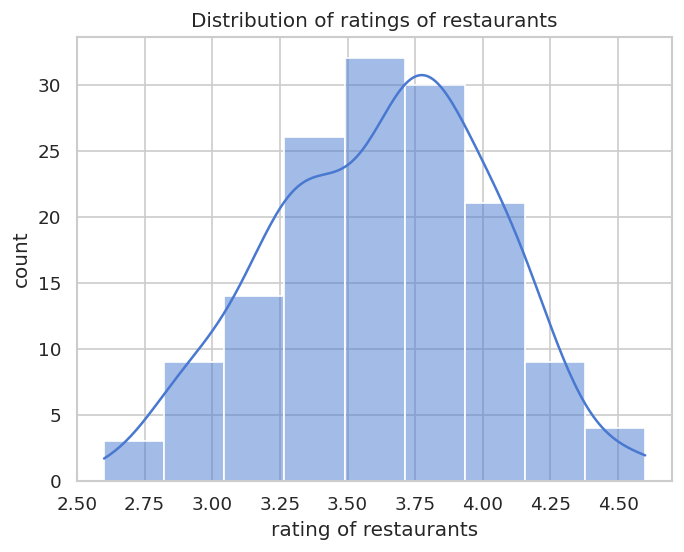

In [13]:
sns.histplot(df['rate'],bins=9,kde=True)
plt.xlabel('rating of restaurants')
plt.ylabel('count')
plt.title('Distribution of ratings of restaurants')

Conclusion: The histogram shows ratings are roughly bell-shaped, skewed slightly toward the 3.5–4.0 range, meaning most restaurants are moderately rated. Very few restaurants fall below 2.5 or above 4.5, suggesting rating inflation is common on Zomato.

Q2- What is the average rating of food that is online ordered and food that is not online ordered ?

In [14]:
dat=df.groupby('online_order',as_index=False)[['rate']].mean()

  online_order      rate
0           No  3.487778
1          Yes  3.858621


<Axes: xlabel='online_order', ylabel='rate'>

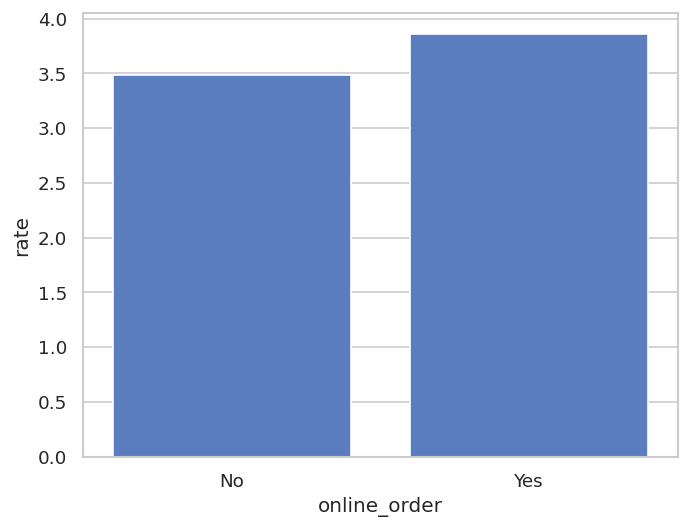

In [15]:
print(dat)
sns.barplot(data=dat,x='online_order',y='rate')

Conclusion: Restaurants that offer online ordering have a higher average rating (3.86) compared to restaurants that do not offer online ordering (3.49). This suggests that online ordering may improve customer convenience and satisfaction, which is reflected in better ratings.

Q3: What proportion of restaurants on Zomato offer online ordering?

In [16]:
Count=df['online_order'].value_counts()
print(Count)

online_order
No     90
Yes    58
Name: count, dtype: int64


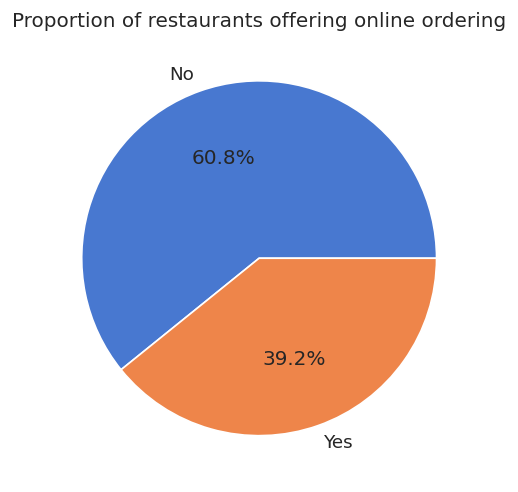

In [17]:
plt.pie(Count,labels=Count.index,autopct='%1.1f%%')
plt.title('Proportion of restaurants offering online ordering')
plt.show()

Conclusion- The majority of restaurants (60.8%) in this dataset do not offer online ordering. Only 39.2% accept online orders, suggesting that offline dining still dominates in this sample.

Q4: How do restaurant ratings vary across different listing types (Dining, Buffet , Cafes, etc.) with the approx cost for two ?

In [18]:
df.groupby('listed_in(type)',as_index=False)[['rate','approx_cost(for two people)']].mean()

,listed_in(type),rate,approx_cost(for two people)
0,Buffet,3.842857,671.428571
1,Cafes,3.765217,545.652174
2,Dining,3.571818,357.272727
3,other,3.912500,668.750000


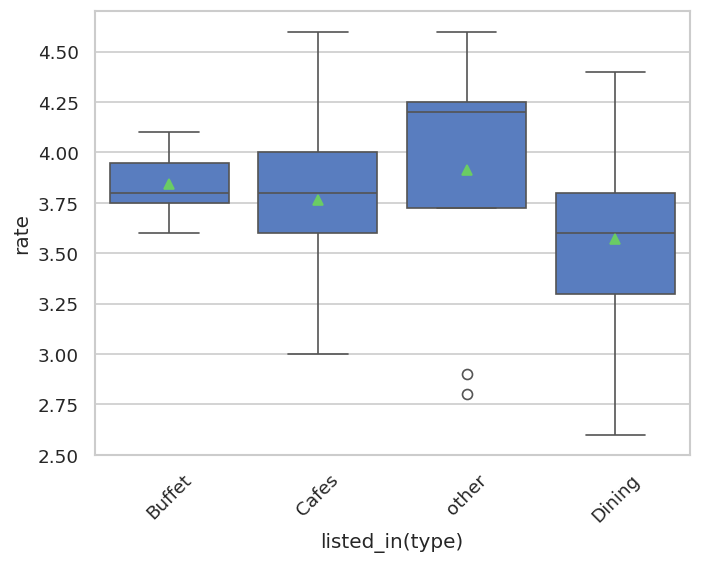

In [19]:
sns.boxplot(data=df,x='listed_in(type)',y='rate',showmeans=True)
plt.xticks(rotation=45)
plt.show()

Conclusion: The 'other' category leads on both average rating (3.91) and average votes (1170.9), despite only having 8 restaurants. Buffet is second in rating (3.84) with a high average cost of ₹671. Cafes follow with 3.77 rating at ₹546 average cost. Dining — the largest category with 110 restaurants — has the lowest average rating (3.57) and lowest cost (₹357). The "other" category's dominance in votes is largely driven by Empire Restaurant (4884 votes) and Onesta (2556 votes), skewing the average significantly.

Q5- Which are the top 10 most popular restaurants based on total customer votes, and what are their average ratings?

In [20]:
Top=df.groupby('name').agg({
    'votes': 'sum',
    'rate': 'mean'
}).sort_values(by='votes', ascending=False).head(10)
print(Top)

                    votes  rate
name                           
Onesta               5112   4.6
Empire Restaurant    4884   4.4
Meghana Foods        4401   4.4
San Churro Cafe      1836   3.8
Kabab Magic          1720   4.1
Szechuan Dragon      1647   4.2
Roving Feast         1047   4.0
Gustoes Beer House    868   4.1
Jeet Restaurant       808   4.0
Recipe                804   4.0


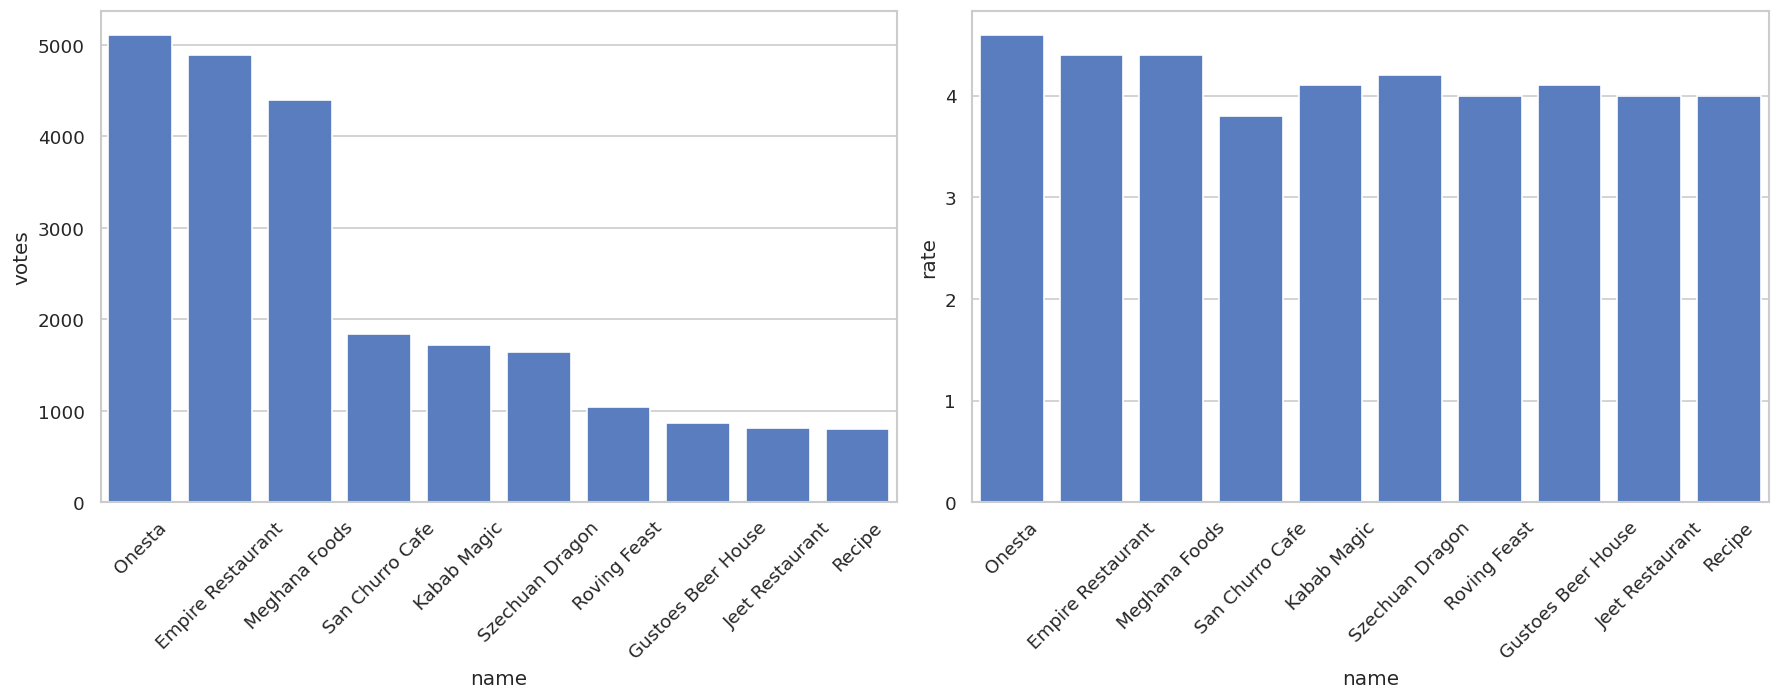

In [21]:
plt.figure(figsize=(15,6))
plt.subplot(1,2,1)
sns.barplot(data=Top,x='name',y='votes')
plt.xticks(rotation=45)
plt.subplot(1,2,2)
sns.barplot(data=Top,x='name',y='rate')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Conclusion:

The analysis shows that Onesta is the most popular restaurant with the highest total customer votes while maintaining an excellent average rating of 4.6. Empire Restaurant and Meghana Foods also receive a high number of votes with strong customer ratings. Overall, restaurants with higher customer engagement generally have good ratings, indicating positive customer satisfaction.

Q6-Which are the top 5 most expensive restaurants based on the approximate cost for two people?

In [22]:
Cos=df.groupby('name',as_index=False)[['approx_cost(for two people)']].mean().sort_values(by='approx_cost(for two people)',ascending=False).head(5)

In [23]:
print(Cos)

                    name  approx_cost(for two people)
8   Ayda Persian Kitchen                        950.0
62         K27 - The Pub                        900.0
18       Cafe Coffee Day                        900.0
12         Beijing Bites                        850.0
60       Jeet Restaurant                        850.0


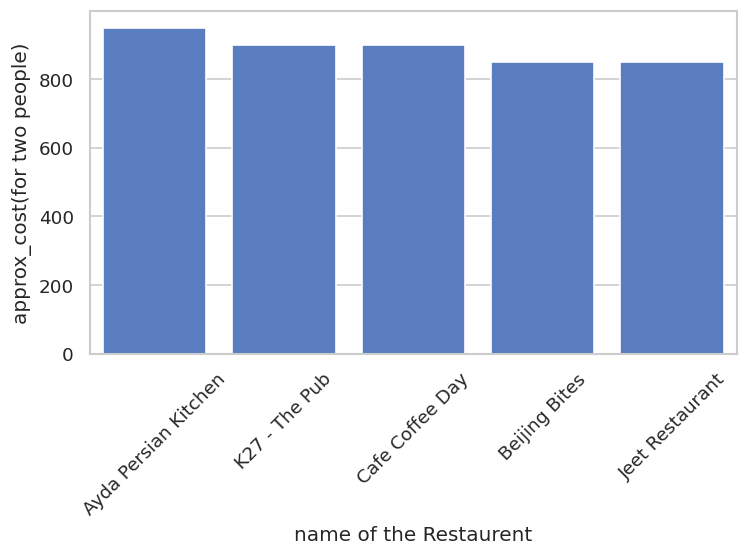

In [24]:
sns.barplot(data=Cos,x='name',y='approx_cost(for two people)')
plt.xlabel('name of the Restaurent')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Conclusion- The analysis shows that Ayda Persian Kitchen has the highest approximate cost for two people at ₹950. K27 – The Pub and Cafe Coffee Day are the next most expensive restaurants, each costing around ₹900. Beijing Bites and Jeet Restaurant follow with an approximate cost of ₹850, indicating that these restaurants fall into the premium pricing category.

Q7- What percentage of restaurants in each restaurant type have a customer rating greater than 4?

In [26]:
Type=df['listed_in(type)'].value_counts()
print(Type)

listed_in(type)
Dining    110
Cafes      23
other       8
Buffet      7
Name: count, dtype: int64


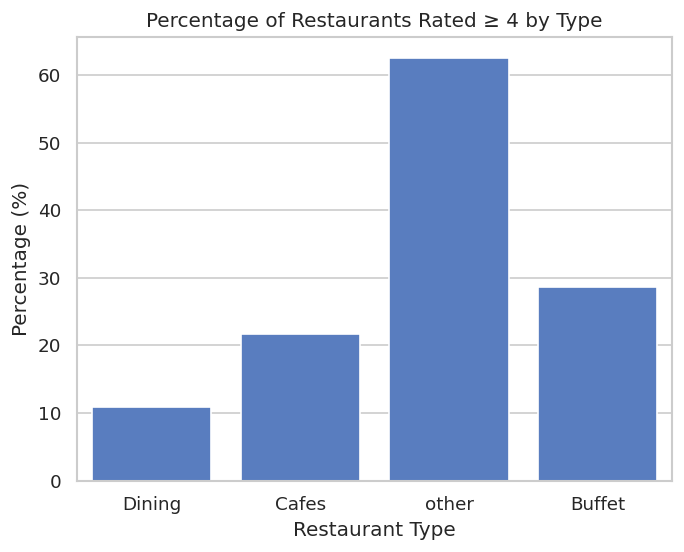

listed_in(type)
Dining    12
Cafes      5
other      5
Buffet     2
Name: count, dtype: int64


In [27]:
high = df[df['rate'] > 4]['listed_in(type)'].value_counts()
total = df['listed_in(type)'].value_counts()
perc=((high / total * 100).round(2))
sns.barplot(x=perc.index,y=perc.values)
plt.title("Percentage of Restaurants Rated ≥ 4 by Type")
plt.xlabel("Restaurant Type")
plt.ylabel("Percentage (%)")
plt.show()
print(high)

Conclusion - The analysis shows that 'Other'restaurant types have the highest percentage of highly rated restaurants, with 62.50%(5/8) receiving a rating above 4, followed by Buffet restaurants at 28.57%(2/7), Cafes at 21.74%(5/23), and Dining restaurants at 10.91%(12/110). This indicates that, although Dining restaurants are the most common in the dataset, the Other category has the highest likelihood of receiving ratings above 4 relative to its total number of restaurants.

Q8- How do the average cost for two people, average customer rating, and average customer votes vary across different restaurant types?

In [28]:
Cost=df.groupby('listed_in(type)')[['rate','approx_cost(for two people)','votes']].mean().sort_values(by='approx_cost(for two people)',ascending=False)
print(Cost)

                     rate  approx_cost(for two people)        votes
listed_in(type)                                                    
Buffet           3.842857                   671.428571   432.571429
other            3.912500                   668.750000  1170.875000
Cafes            3.765217                   545.652174   279.739130
Dining           3.571818                   357.272727   185.118182


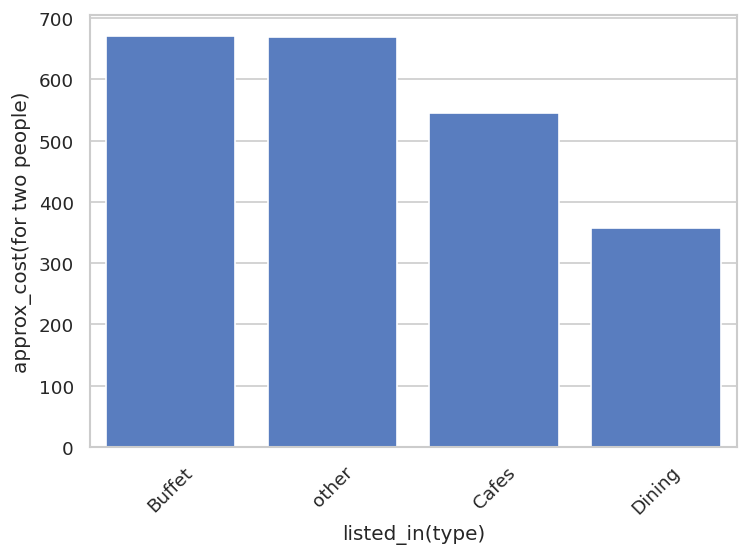

In [29]:
sns.barplot(data=Cost,x='listed_in(type)',y='approx_cost(for two people)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



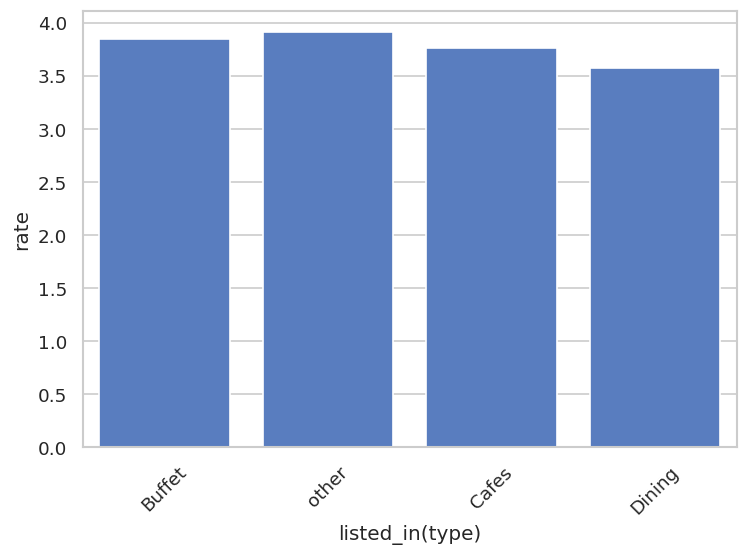

In [30]:
sns.barplot(data=Cost,x='listed_in(type)',y='rate')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



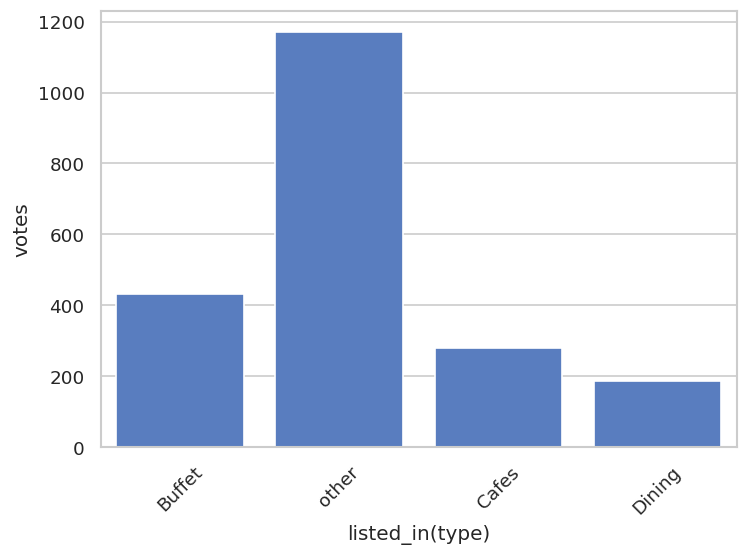

In [31]:
sns.barplot(data=Cost,x='listed_in(type)',y='votes')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Conclusion- The analysis shows that Dining and Other restaurant types have the highest average cost for two people (around ₹670), while Buffet restaurants have the lowest average cost (around ₹360). In terms of customer ratings, Other restaurants have the highest average rating (around 3.9), followed by Buffet (around 3.85), Cafes (around 3.75), and Dining (around 3.6). Other restaurants also receive the highest average number of customer votes (around 1,170), followed by Buffet (around 430), Cafes (around 280), and Dining (around 180), indicating that they are the most expensive, best-rated, and most popular restaurant category in the dataset.